In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# Cell 1: Environment Setup, Repository Cloning, & Library Imports

!pip install -q sentence-transformers

import os
if not os.path.exists('/kaggle/working/ESC'):
    os.system('git clone https://github.com/Yiwei98/ESC.git /kaggle/working/ESC')

os.chdir('/kaggle/working/ESC')
print(f"Working directory: {os.getcwd()}")

import json
import re
import random
import time
import requests
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer, util
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model_embedder = SentenceTransformer('all-mpnet-base-v2', device=device)
print("Encoder loaded ✅")

Cloning into '/kaggle/working/ESC'...


Working directory: /kaggle/working/ESC
Device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoder loaded ✅


In [6]:
# Cell 2: Helper Functions & Text Processing

ANS_RE = re.compile(r"#### (\-?[0-9\.\,]+)")
INVALID_ANS = "[invalid]"

def extract_gold_answer(completion):
    match = ANS_RE.search(completion)
    if match:
        return str(match.group(1).strip().replace(",", ""))
    return INVALID_ANS

def extract_predicted_number(text):
    number_list = re.findall(r"\d+\.?\d*", text)
    try:
        return str(number_list[-1].strip('.'))
    except IndexError:
        return "-1000"

def extract_gold_answer_strategy(answer):
    if isinstance(answer, dict):
        return 'yes' if answer.get('Yes', 0) == 1 else 'no'
    s = str(answer).lower()
    return 'yes' if "'yes': 1" in s or '"yes": 1' in s else 'no'

def extract_predicted_strategy(text):
    text = str(text).lower().strip()
    for sent in reversed(text.split('.')):
        sent = sent.strip()
        if sent.endswith('yes') or ' yes' in sent[-15:] or sent.startswith('yes'):
            return 'yes'
        if sent.endswith('no') or ' no' in sent[-15:] or sent.startswith('no'):
            return 'no'
    if 'yes' in text: return 'yes'
    if 'no'  in text: return 'no'
    return '[invalid]'

def extract_final_answer(text, task_type):
    if task_type == 'gsm8k':
        return extract_predicted_number(text)
    else:
        return extract_predicted_strategy(text)

def calculate_similarity_from_embeddings(all_embeddings, start, end):
    window_emb = all_embeddings[start:end]
    if len(window_emb) <= 1:
        return 1.0
    sim_matrix   = util.cos_sim(window_emb, window_emb).cpu().numpy()
    triu_indices = np.triu_indices_from(sim_matrix, k=1)
    return float(np.mean(sim_matrix[triu_indices]))

In [13]:
import os, shutil, pandas as pd

os.makedirs("/kaggle/working/ESC/GPT-OSS-20B_result/gsm8k",   exist_ok=True)
os.makedirs("/kaggle/working/ESC/GPT-OSS-20B_result/strategy", exist_ok=True)

# Copy files
shutil.copy("/kaggle/input/datasets/leenmasaadeh/results/T0.7 (8).jsonl",
            "/kaggle/working/ESC/GPT-OSS-20B_result/gsm8k/T0.7.jsonl")

shutil.copy("/kaggle/input/datasets/leenmasaadeh/results/T0.7 startegyfull.jsonl",
            "/kaggle/working/ESC/GPT-OSS-20B_result/strategy/T0.7.jsonl")

# Restore simulation results
df_results = pd.read_csv("/kaggle/input/datasets/leenmasaadeh/results/simulation_results.csv")
simulation_results = df_results.to_dict('records')

print(f"✅ GSM8K: {open('/kaggle/working/ESC/GPT-OSS-20B_result/gsm8k/T0.7.jsonl').readlines().__len__()} questions")
print(f"✅ Strategy: {open('/kaggle/working/ESC/GPT-OSS-20B_result/strategy/T0.7.jsonl').readlines().__len__()} questions")
print(f"✅ Simulation results: {len(simulation_results)} rows")

✅ GSM8K: 200 questions
✅ Strategy: 200 questions
✅ Simulation results: 7608 rows


In [12]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/leenmasaadeh/results/T0.7 startegyfull.jsonl
/kaggle/input/datasets/leenmasaadeh/results/T0.7 (8).jsonl
/kaggle/input/datasets/leenmasaadeh/results/simulation_results.csv



Loaded 1318 questions for GPT3.5 / gsm8k
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 2...
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 5...
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 10...
  → MAX_SAMPLES: 40 | WINDOW_SIZE: 2...
  → MAX_SAMPLES: 40 | WINDOW_SIZE: 5...
  → MAX_SAMPLES: 40 | WINDOW_SIZE: 10...

Loaded 1319 questions for GPT4 / gsm8k
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 2...
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 5...
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 10...
  → MAX_SAMPLES: 40 | WINDOW_SIZE: 2...
  → MAX_SAMPLES: 40 | WINDOW_SIZE: 5...
  → MAX_SAMPLES: 40 | WINDOW_SIZE: 10...

Loaded 200 questions for GPT-OSS-20B / gsm8k
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 2...
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 5...
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 10...
  → MAX_SAMPLES: 40 | WINDOW_SIZE: 2...
  → MAX_SAMPLES: 40 | WINDOW_SIZE: 5...
  → MAX_SAMPLES: 40 | WINDOW_SIZE: 10...

Loaded 2281 questions for GPT3.5 / strategy
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 2...
  → MAX_SAMPLES: 20 | WINDOW_SIZE: 5...
  → MAX_SAMPLES: 20 |

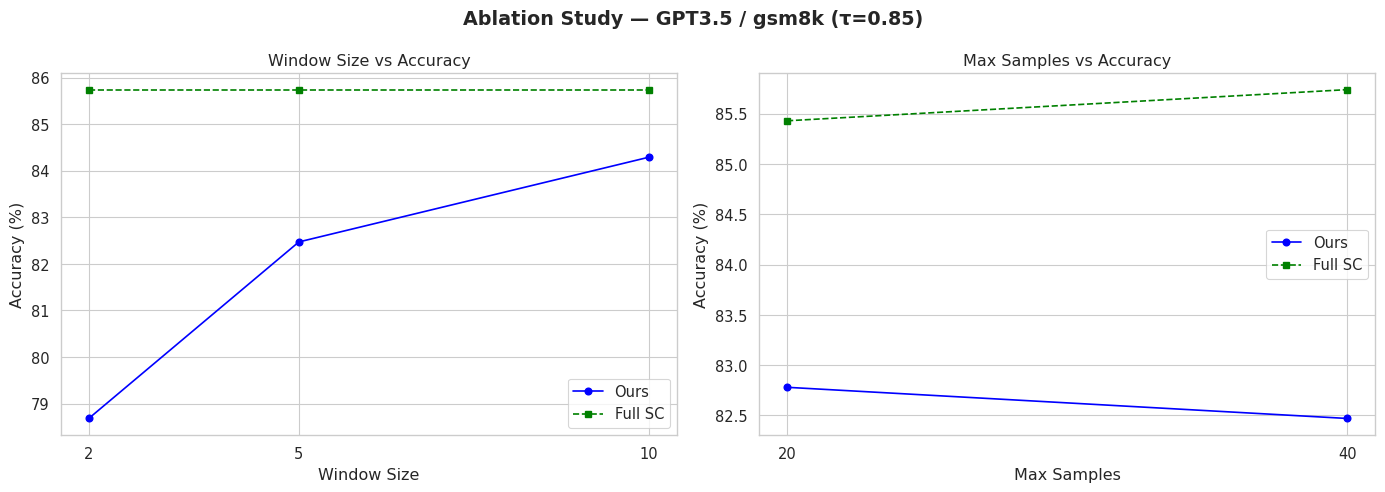

✅ Saved: ablation_GPT3.5_gsm8k.png


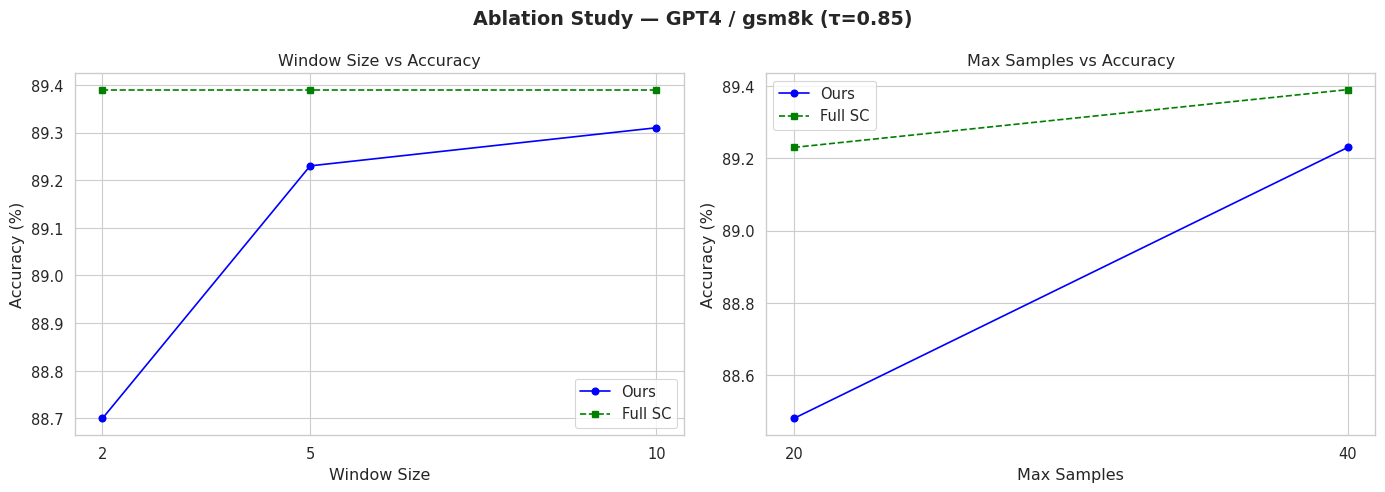

✅ Saved: ablation_GPT4_gsm8k.png


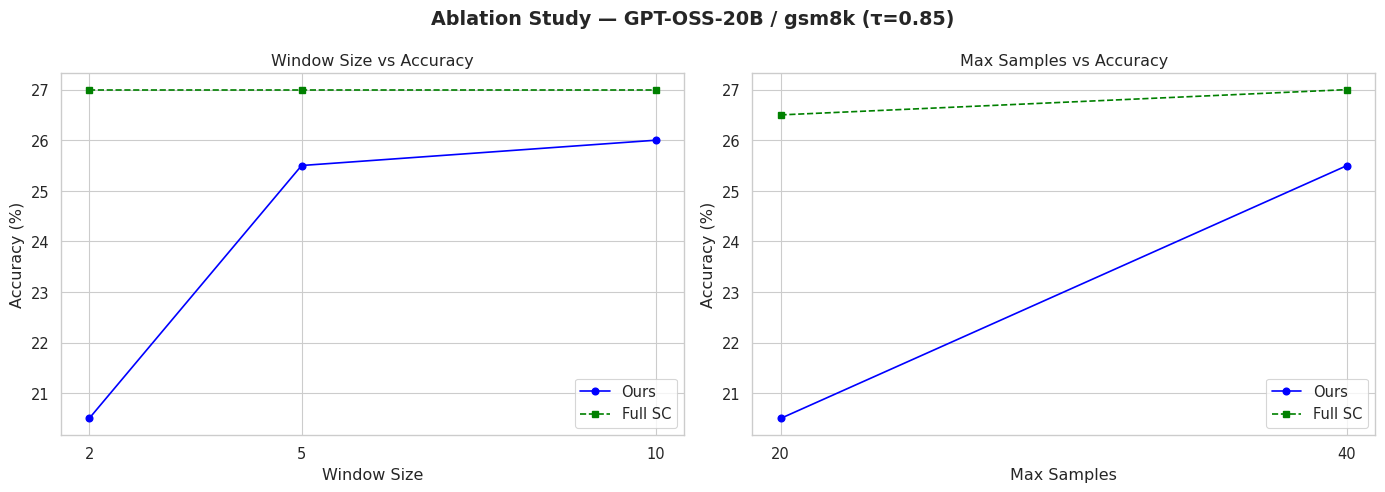

✅ Saved: ablation_GPT-OSS-20B_gsm8k.png


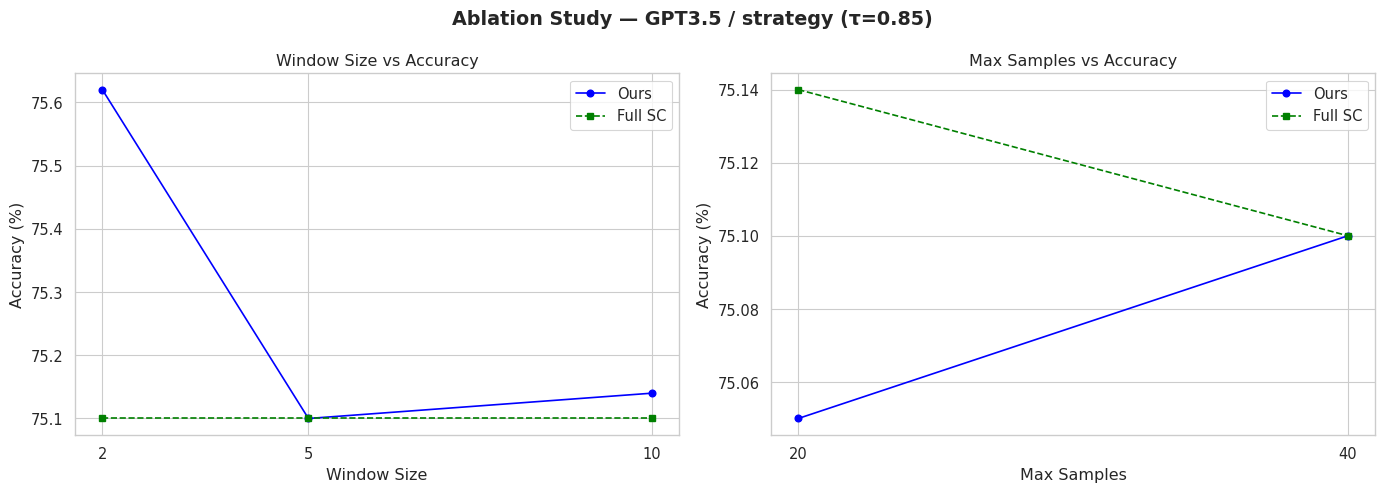

✅ Saved: ablation_GPT3.5_strategy.png


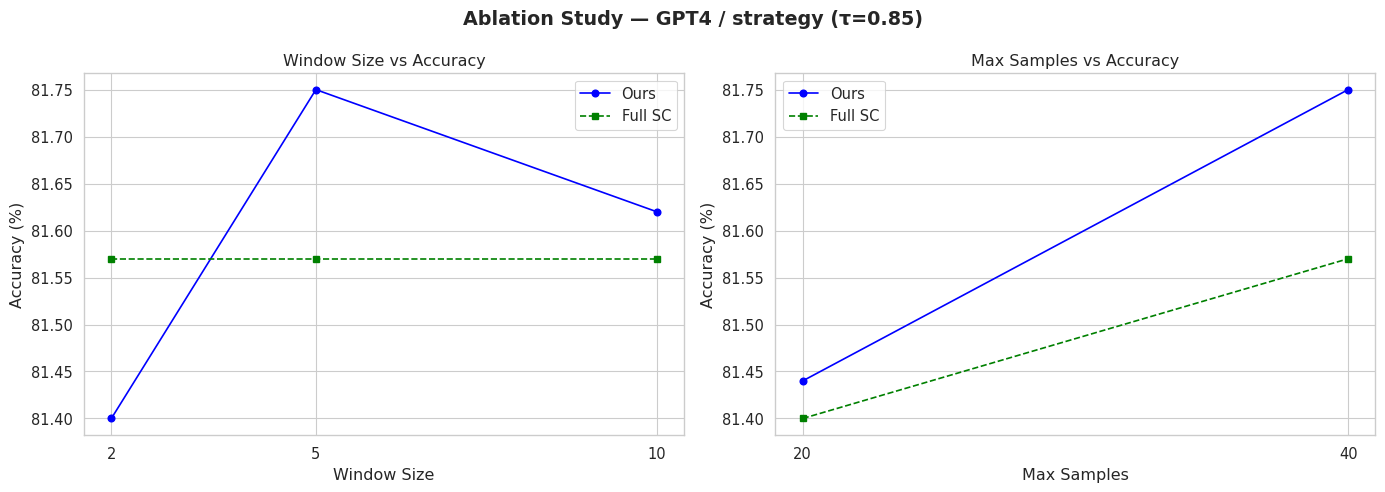

✅ Saved: ablation_GPT4_strategy.png


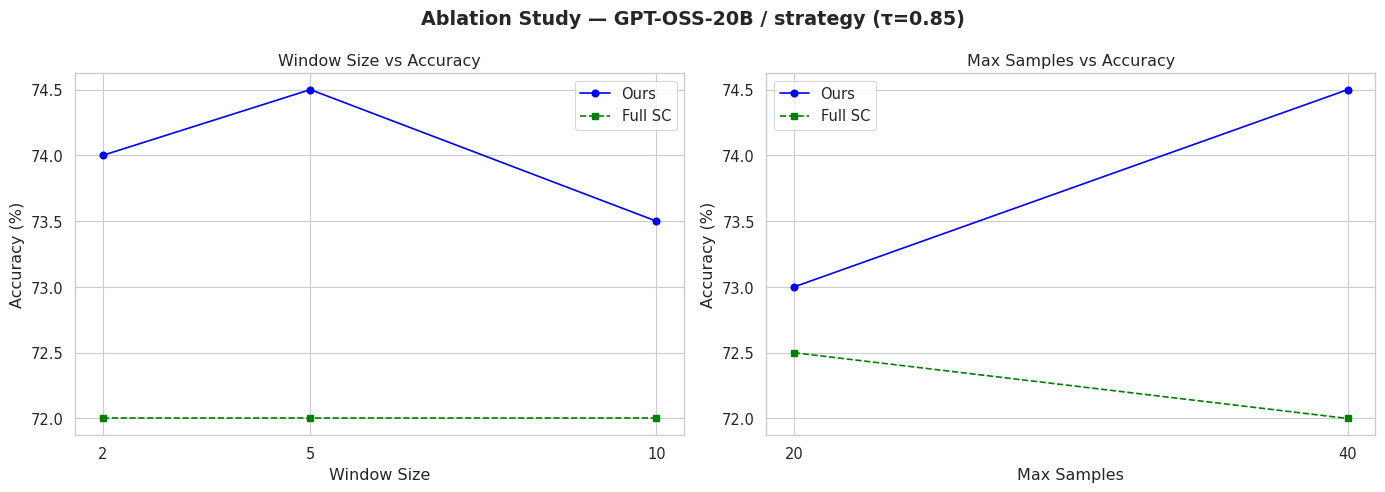

✅ Saved: ablation_GPT-OSS-20B_strategy.png


In [14]:
# Ablation Study Grid Search

import json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

def run_ablation_study(tasks_to_run=["gsm8k", "strategy"],
                        models_to_run=["GPT3.5", "GPT4", "GPT-OSS-20B"],
                        window_sizes=[2, 5, 10],
                        max_samples_list=[20, 40],
                        thresholds=[0.85],
                        sample_n=None):

    ablation_results = []

    for TASK_TYPE in tasks_to_run:
        for MODEL_TYPE in models_to_run:
            FILE_PATH = f"{MODEL_TYPE}_result/{TASK_TYPE}/T0.7.jsonl"
            try:
                with open(FILE_PATH, "r", encoding="utf-8") as f:
                    all_data = f.readlines()
                if sample_n is not None:
                    all_data = all_data[:sample_n]
                print(f"\nLoaded {len(all_data)} questions for {MODEL_TYPE} / {TASK_TYPE}")
            except FileNotFoundError:
                print(f"File not found: {FILE_PATH} — Skipping!")
                continue

            for max_samples in max_samples_list:
                for window_size in window_sizes:
                    if max_samples % window_size != 0:
                        continue

                    print(f"  → MAX_SAMPLES: {max_samples} | WINDOW_SIZE: {window_size}...")
                    random.seed(0)

                    correct_sc   = 0
                    correct_esc  = 0
                    correct_ours = {t: 0 for t in thresholds}

                    samples_spent_esc  = 0
                    samples_spent_ours = {t: 0 for t in thresholds}

                    for line in all_data:
                        tem      = json.loads(line)
                        gold_ans = extract_gold_answer(tem['answer']) if TASK_TYPE == 'gsm8k' else extract_gold_answer_strategy(tem['answer'])

                        shu_batch = tem['generated_answer'][:max_samples]
                        random.shuffle(shu_batch)

                        all_embeddings = model_embedder.encode(shu_batch, convert_to_tensor=True)

                        baseline_stop_window  = max_samples
                        baseline_stopped      = False
                        semantic_stop_windows = {t: max_samples for t in thresholds}
                        active_thresholds     = list(thresholds)

                        for w_idx in range(max_samples // window_size):
                            current_samples_count = (w_idx + 1) * window_size
                            current_window_texts  = shu_batch[w_idx * window_size : current_samples_count]

                            if not baseline_stopped:
                                window_preds = [extract_final_answer(t, TASK_TYPE) for t in current_window_texts]
                                if len(set(window_preds)) == 1:
                                    baseline_stop_window = current_samples_count
                                    baseline_stopped     = True

                            if active_thresholds:
                                semantic_sim = calculate_similarity_from_embeddings(
                                    all_embeddings, w_idx * window_size, current_samples_count
                                )
                                for t in list(active_thresholds):
                                    if semantic_sim >= t:
                                        semantic_stop_windows[t] = current_samples_count
                                        active_thresholds.remove(t)

                            if baseline_stopped and not active_thresholds:
                                break

                        samples_spent_esc += baseline_stop_window

                        full_preds    = [extract_final_answer(t, TASK_TYPE) for t in shu_batch]
                        full_majority = max(set(full_preds), key=full_preds.count)
                        if full_majority == gold_ans:
                            correct_sc += 1

                        bl_preds    = [extract_final_answer(t, TASK_TYPE) for t in shu_batch[:baseline_stop_window]]
                        bl_majority = max(set(bl_preds), key=bl_preds.count)
                        if bl_majority == gold_ans:
                            correct_esc += 1

                        for t in thresholds:
                            stop_w = semantic_stop_windows[t]
                            samples_spent_ours[t] += stop_w
                            preds  = [extract_final_answer(x, TASK_TYPE) for x in shu_batch[:stop_w]]
                            sem_majority = max(set(preds), key=preds.count)
                            if sem_majority == gold_ans:
                                correct_ours[t] += 1

                    num_q = len(all_data)
                    for t in thresholds:
                        avg_samples_ours = samples_spent_ours[t] / num_q
                        saved_cost_ours  = ((max_samples - avg_samples_ours) / max_samples) * 100
                        ablation_results.append({
                            'Model':                    MODEL_TYPE,
                            'Task':                     TASK_TYPE,
                            'Max Samples Limit':        max_samples,
                            'Window Size':              window_size,
                            'Ours Avg Samples':         round(avg_samples_ours, 2),
                            'Ours Saved Cost (%)':      f"{saved_cost_ours:.2f}%",
                            'Ours Accuracy (%)':        round((correct_ours[t] / num_q) * 100, 2),
                            'Standard SC Accuracy (%)': round((correct_sc / num_q) * 100, 2)
                        })

    return pd.DataFrame(ablation_results)

# ── Run Ablation ──────────────────────────────────────────────────────────────
df_ablation_matrix = run_ablation_study(
    tasks_to_run     = ["gsm8k", "strategy"],
    models_to_run    = ["GPT3.5", "GPT4", "GPT-OSS-20B"],
    window_sizes     = [2, 5, 10],
    max_samples_list = [20, 40],
    thresholds       = [0.85],
    sample_n         = None  # ← full dataset ✅
)

print("\n" + "="*60)
print("             ABLATION STUDY MATRIX")
print("="*60)
print(df_ablation_matrix.to_string(index=False))

# ── Save table to Kaggle output ───────────────────────────────────────────────
df_ablation_matrix.to_csv("/kaggle/working/ablation_results.csv", index=False)
print("✅ Ablation results saved!")

# ── Plots ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

for task in ["gsm8k", "strategy"]:
    for model in ["GPT3.5", "GPT4", "GPT-OSS-20B"]:

        df_sub = df_ablation_matrix[
            (df_ablation_matrix['Task']  == task) &
            (df_ablation_matrix['Model'] == model)
        ]
        if df_sub.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Ablation Study — {model} / {task} (τ=0.85)', fontweight='bold')

        df_w = df_sub[df_sub['Max Samples Limit'] == 40]
        axes[0].plot(df_w['Window Size'], df_w['Ours Accuracy (%)'],
                     marker='o', color='blue', label='Ours')
        axes[0].plot(df_w['Window Size'], df_w['Standard SC Accuracy (%)'],
                     marker='s', color='green', linestyle='--', label='Full SC')
        axes[0].set_title('Window Size vs Accuracy')
        axes[0].set_xlabel('Window Size')
        axes[0].set_ylabel('Accuracy (%)')
        axes[0].set_xticks([2, 5, 10])
        axes[0].legend()

        df_m = df_sub[df_sub['Window Size'] == 5]
        axes[1].plot(df_m['Max Samples Limit'], df_m['Ours Accuracy (%)'],
                     marker='o', color='blue', label='Ours')
        axes[1].plot(df_m['Max Samples Limit'], df_m['Standard SC Accuracy (%)'],
                     marker='s', color='green', linestyle='--', label='Full SC')
        axes[1].set_title('Max Samples vs Accuracy')
        axes[1].set_xlabel('Max Samples')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_xticks([20, 40])
        axes[1].legend()

        plt.tight_layout()
        plt.savefig(f"/kaggle/working/ablation_{model}_{task}.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: ablation_{model}_{task}.png")

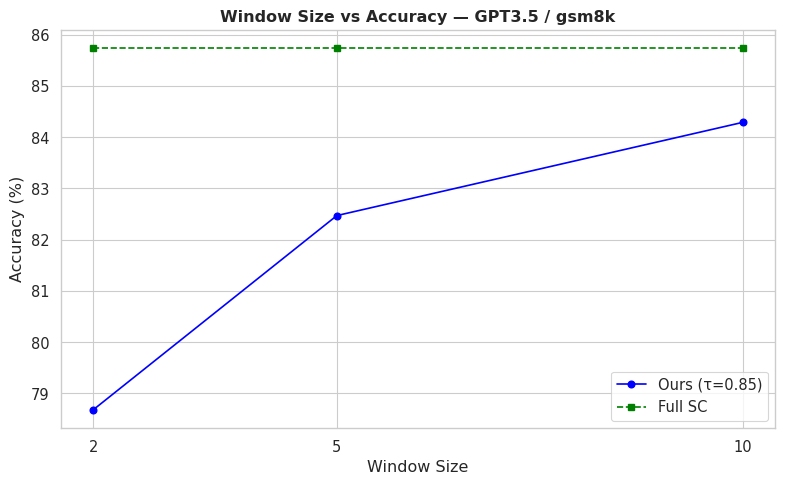

✅ Saved: ablation_window_GPT3.5_gsm8k.png


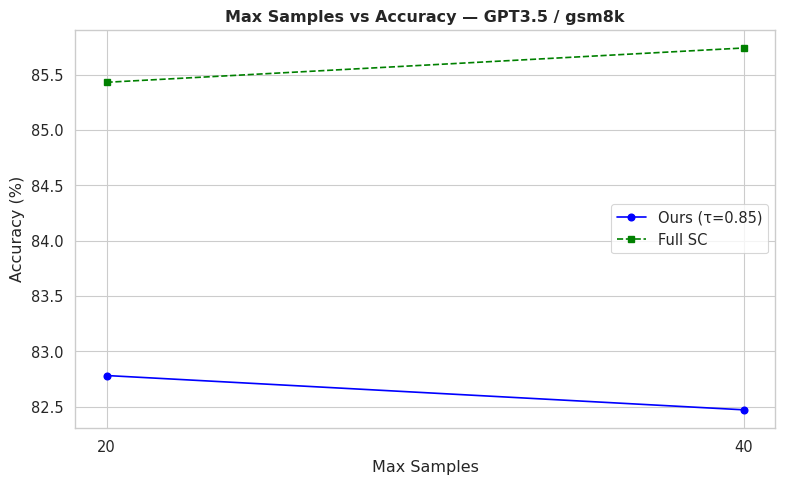

✅ Saved: ablation_maxsamples_GPT3.5_gsm8k.png


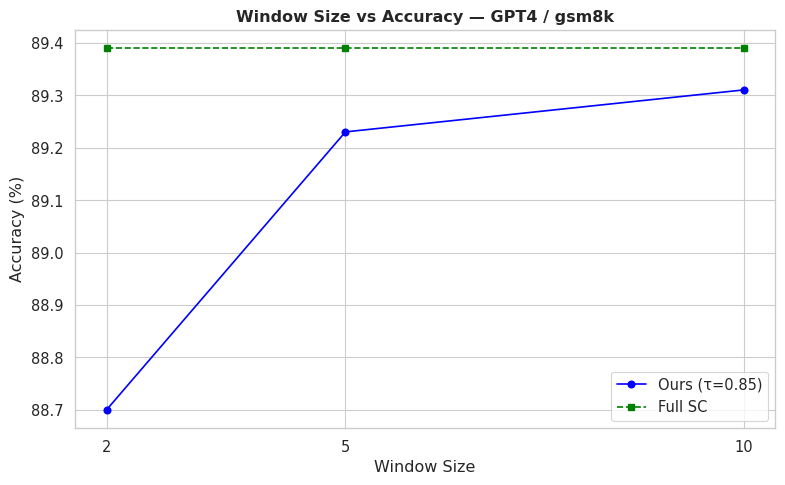

✅ Saved: ablation_window_GPT4_gsm8k.png


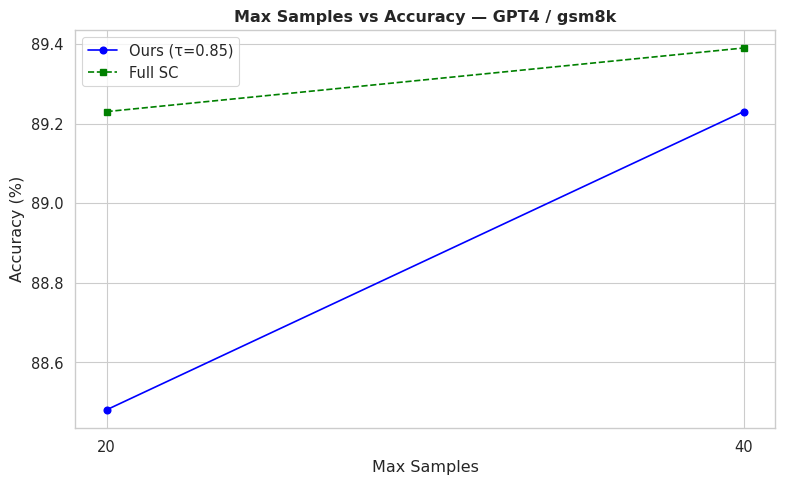

✅ Saved: ablation_maxsamples_GPT4_gsm8k.png


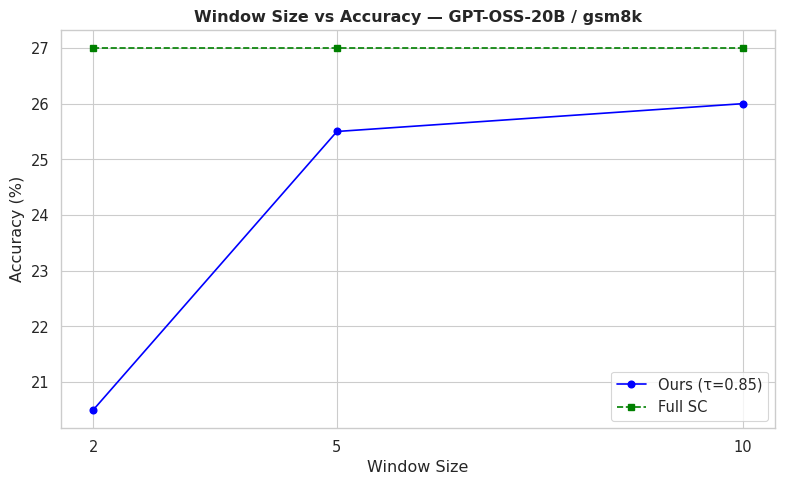

✅ Saved: ablation_window_GPT-OSS-20B_gsm8k.png


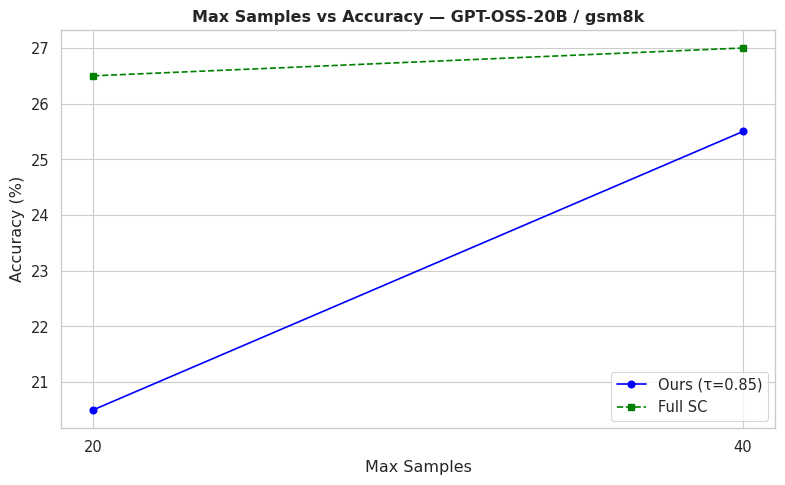

✅ Saved: ablation_maxsamples_GPT-OSS-20B_gsm8k.png


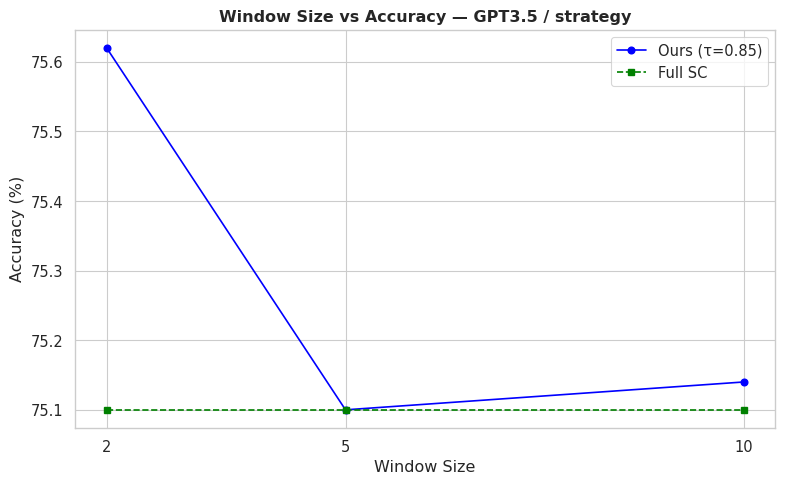

✅ Saved: ablation_window_GPT3.5_strategy.png


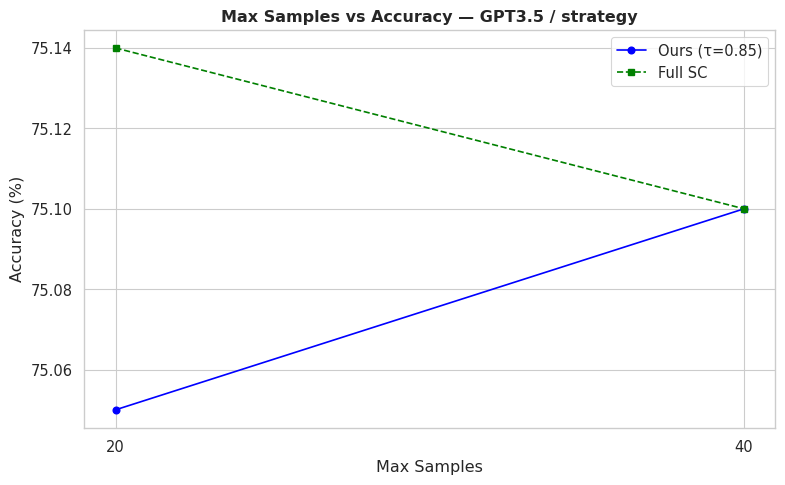

✅ Saved: ablation_maxsamples_GPT3.5_strategy.png


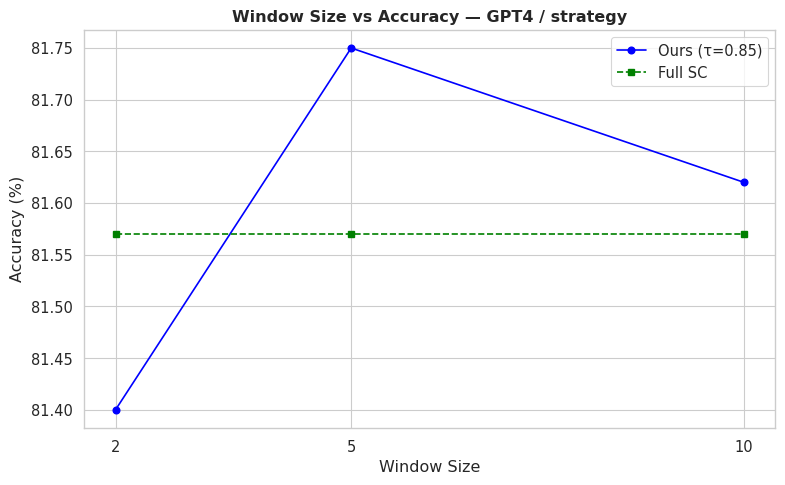

✅ Saved: ablation_window_GPT4_strategy.png


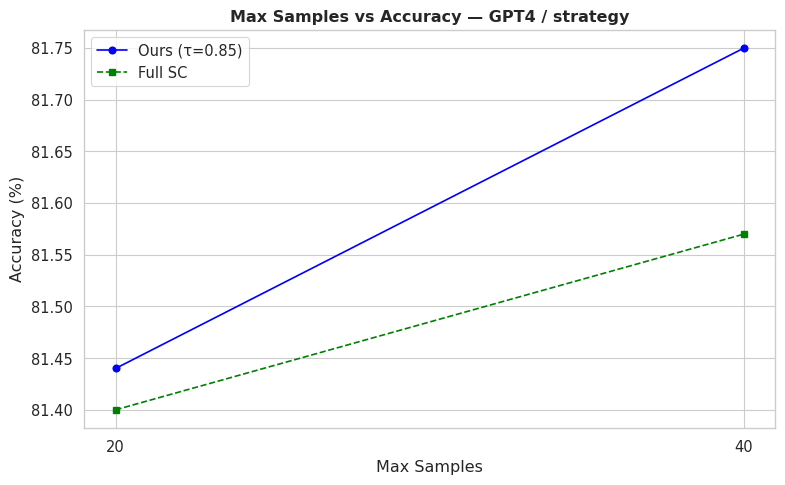

✅ Saved: ablation_maxsamples_GPT4_strategy.png


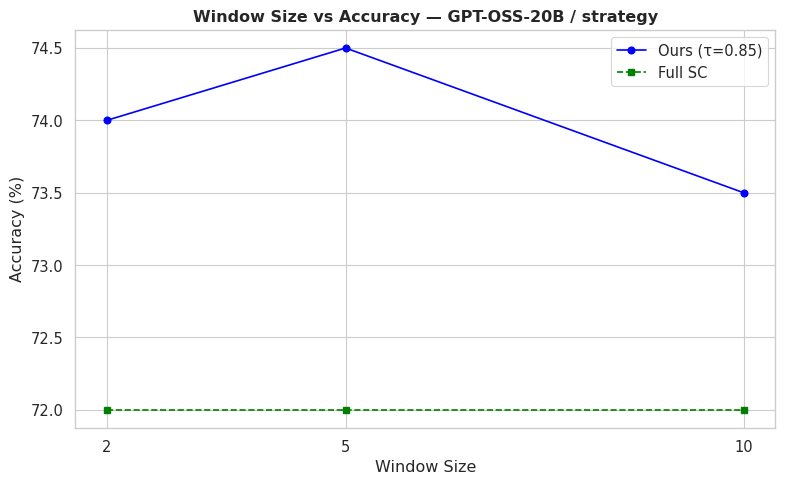

✅ Saved: ablation_window_GPT-OSS-20B_strategy.png


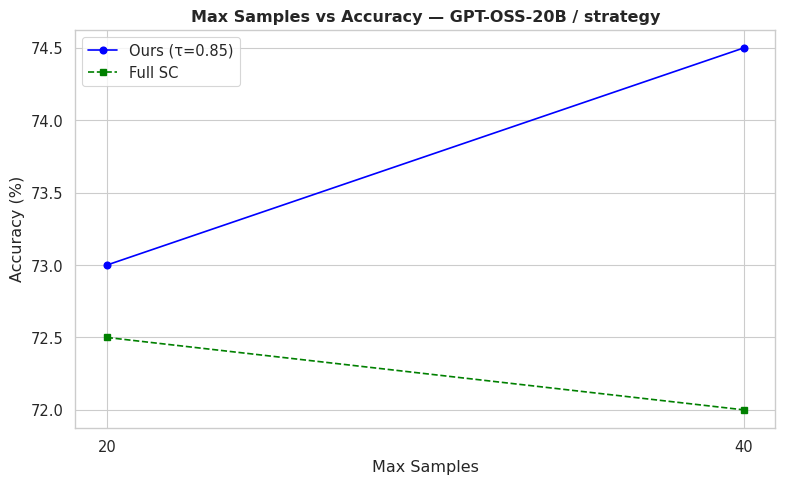

✅ Saved: ablation_maxsamples_GPT-OSS-20B_strategy.png


In [15]:
# Save ablation plots as separate figures

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

for task in ["gsm8k", "strategy"]:
    for model in ["GPT3.5", "GPT4", "GPT-OSS-20B"]:

        df_sub = df_ablation_matrix[
            (df_ablation_matrix['Task']  == task) &
            (df_ablation_matrix['Model'] == model)
        ]
        if df_sub.empty:
            continue

        # ── Plot 1: Window Size vs Accuracy ───────────────────────────────────
        fig, ax = plt.subplots(figsize=(8, 5))
        df_w = df_sub[df_sub['Max Samples Limit'] == 40]
        ax.plot(df_w['Window Size'], df_w['Ours Accuracy (%)'],
                marker='o', color='blue', label='Ours (τ=0.85)')
        ax.plot(df_w['Window Size'], df_w['Standard SC Accuracy (%)'],
                marker='s', color='green', linestyle='--', label='Full SC')
        ax.set_title(f'Window Size vs Accuracy — {model} / {task}', fontweight='bold')
        ax.set_xlabel('Window Size')
        ax.set_ylabel('Accuracy (%)')
        ax.set_xticks([2, 5, 10])
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"/kaggle/working/ablation_window_{model}_{task}.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: ablation_window_{model}_{task}.png")

        # ── Plot 2: Max Samples vs Accuracy ───────────────────────────────────
        fig, ax = plt.subplots(figsize=(8, 5))
        df_m = df_sub[df_sub['Window Size'] == 5]
        ax.plot(df_m['Max Samples Limit'], df_m['Ours Accuracy (%)'],
                marker='o', color='blue', label='Ours (τ=0.85)')
        ax.plot(df_m['Max Samples Limit'], df_m['Standard SC Accuracy (%)'],
                marker='s', color='green', linestyle='--', label='Full SC')
        ax.set_title(f'Max Samples vs Accuracy — {model} / {task}', fontweight='bold')
        ax.set_xlabel('Max Samples')
        ax.set_ylabel('Accuracy (%)')
        ax.set_xticks([20, 40])
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"/kaggle/working/ablation_maxsamples_{model}_{task}.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: ablation_maxsamples_{model}_{task}.png")

In [16]:
# Save ablation results
df_ablation_matrix.to_csv("/kaggle/working/ablation_results.csv", index=False)
print("✅ Ablation results saved!")

✅ Ablation results saved!


In [18]:
# Download all results and figures

from IPython.display import FileLink, display
import os

# ── List all files to download ────────────────────────────────────────────────
files_to_download = []

# CSV results
files_to_download.append("/kaggle/working/ablation_results.csv")

# All PNG figures
for f in os.listdir("/kaggle/working"):
    if f.endswith(".png"):
        files_to_download.append(f"/kaggle/working/{f}")

print(f"Files ready to download ({len(files_to_download)} total):\n")
for f in files_to_download:
    print(f"  {os.path.basename(f)}")
    display(FileLink(f))

Files ready to download (19 total):

  ablation_results.csv


/kaggle/working/ablation_results.csv

  ablation_maxsamples_GPT3.5_gsm8k.png


/kaggle/working/ablation_maxsamples_GPT3.5_gsm8k.png

  ablation_maxsamples_GPT-OSS-20B_strategy.png


...

/kaggle/working/ablation_GPT3.5_gsm8k.png

  ablation_maxsamples_GPT4_strategy.png


/kaggle/working/ablation_maxsamples_GPT4_strategy.png

  ablation_window_GPT3.5_strategy.png


/kaggle/working/ablation_window_GPT3.5_strategy.png

In [19]:
import zipfile, os

zip_path = "/kaggle/working/ablation_results.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write("/kaggle/working/ablation_results.csv", "ablation_results.csv")
    for f in os.listdir("/kaggle/working"):
        if f.endswith(".png"):
            zipf.write(f"/kaggle/working/{f}", f)

print("✅ Zip created!")
display(FileLink(zip_path))

✅ Zip created!


/kaggle/working/ablation_results.zip